In [77]:
import seaborn as sns
import pandas as pd
import tabula
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#powerball_data_url = "https://files.floridalottery.com/exptkt/pb.pdf"

## Data cleaning ans sanitation

In [3]:
# ignore first page ==> additional content creates a reading error
df_lst_raw = tabula.read_pdf("pb.pdf", pages=[x for x in range(2, 90)])

Failed to import jpype dependencies. Fallback to subprocess.
No module named 'jpype'


In [4]:
len(df_lst_raw)

176

Why are there 176 elements instad of just 89?

In [5]:
df_lst_raw[0].head()

,Draw Date,Winning Numbers,Game,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,7/6/26,17,44,63,66,67,PB 4,X2,POWERBALL
1,7/6/26,22,25,27,47,50,PB 21,NaN,POWERBALL DP
2,7/4/26,17,38,46,50,69,PB 20,X2,POWERBALL
3,7/4/26,4,19,24,25,41,PB 9,NaN,POWERBALL DP
4,7/1/26,2,6,26,39,68,PB 6,X2,POWERBALL


In [6]:
df_lst_raw[1]

,Pages2/90


Thats it! `tabula` is reading the page numbers as separate table. Those can be easily excluded by filtering out using the column name

In [7]:
df = df_lst_raw[0]
for _df in  df_lst_raw[2:]:
    if not any("Pages" in c for c in _df.columns):
        df = pd.concat([df, _df], axis=0, ignore_index=True)

In [8]:
df.head()

,Draw Date,Winning Numbers,Game,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,7/6/26,17,44,63,66,67,PB 4,X2,POWERBALL
1,7/6/26,22,25,27,47,50,PB 21,NaN,POWERBALL DP
2,7/4/26,17,38,46,50,69,PB 20,X2,POWERBALL
3,7/4/26,4,19,24,25,41,PB 9,NaN,POWERBALL DP
4,7/1/26,2,6,26,39,68,PB 6,X2,POWERBALL


The column names are all messed up, lets fix them.

In [9]:
df = df.rename(columns = {"Draw Date": "date",
                     "Winning Numbers": "win_num_1",
                     "Game": "win_num_2",
                     "Unnamed: 0": "win_num_3",
                     "Unnamed: 1": "win_num_4",
                     "Unnamed: 2": "win_num_5",
                     "Unnamed: 3": "pb", # Power Ball number
                     "Unnamed: 4": "pp", # Power Ball multiplier
                     "Unnamed: 5": "game"})

In [10]:
df.head()

,date,win_num_1,win_num_2,win_num_3,win_num_4,win_num_5,pb,pp,game
0,7/6/26,17,44,63,66,67,PB 4,X2,POWERBALL
1,7/6/26,22,25,27,47,50,PB 21,NaN,POWERBALL DP
2,7/4/26,17,38,46,50,69,PB 20,X2,POWERBALL
3,7/4/26,4,19,24,25,41,PB 9,NaN,POWERBALL DP
4,7/1/26,2,6,26,39,68,PB 6,X2,POWERBALL


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2816 entries, 0 to 2815
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   date       2816 non-null   str  
 1   win_num_1  2816 non-null   int64
 2   win_num_2  2816 non-null   int64
 3   win_num_3  2816 non-null   int64
 4   win_num_4  2816 non-null   int64
 5   win_num_5  2816 non-null   int64
 6   pb         2816 non-null   str  
 7   pp         2053 non-null   str  
 8   game       2816 non-null   str  
dtypes: int64(5), str(4)
memory usage: 198.1 KB


Much better, but there's still some problemns. The `pb` and `pp` columns are `str` type and need to be `int`. Before they can be casted, the additinal characters (PB, X) must be removed from each column. The date is also a `str`, so needs to be converted to a date type if date operation are needed.

In [12]:
df['pb'] = df['pb'].str.replace('PB ', '', regex=False)
df['pp'] = df['pp'].str.replace('X', '', regex=False)

In [13]:
df['pb'] = df['pb'].astype(int)
# the astype method cannot be used directly with the pp column since it contain NaN strings which cannot be
# casted to int directly. Instead we use the to_numeric method with the "coerce" option which forces the casting
# on the valid elements but asigns NaN to the unvalid ones.
df['pp'] = pd.to_numeric(df['pp'], errors="coerce").astype("Int64")
df["date"] = pd.to_datetime(df["date"])

/tmp/ipykernel_650843/2125900464.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


In [14]:
df.head()

,date,win_num_1,win_num_2,win_num_3,win_num_4,win_num_5,pb,pp,game
0,2026-07-06,17,44,63,66,67,4,2,POWERBALL
1,2026-07-06,22,25,27,47,50,21,<NA>,POWERBALL DP
2,2026-07-04,17,38,46,50,69,20,2,POWERBALL
3,2026-07-04,4,19,24,25,41,9,<NA>,POWERBALL DP
4,2026-07-01,2,6,26,39,68,6,2,POWERBALL


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2816 entries, 0 to 2815
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       2816 non-null   datetime64[us]
 1   win_num_1  2816 non-null   int64         
 2   win_num_2  2816 non-null   int64         
 3   win_num_3  2816 non-null   int64         
 4   win_num_4  2816 non-null   int64         
 5   win_num_5  2816 non-null   int64         
 6   pb         2816 non-null   int64         
 7   pp         2053 non-null   Int64         
 8   game       2816 non-null   str           
dtypes: Int64(1), datetime64[us](1), int64(6), str(1)
memory usage: 200.9 KB


Data looks good now, so we can go ahead and save the cleaned version to disk.

In [16]:
df.to_csv("powerball_numbers_cleaned.csv", index=False)

## Consistency Checks

In the powerball drawing, the number of the 5 white balls should be in the range `[1-69]`. The red ball (power ball) numbers should be in the range `[1-26]`

In [17]:
assert df[[f"win_num_{x}" for x in range(1,6)]].min(axis=None) >= 1,  "White ball numbers out of range!"
assert df[[f"win_num_{x}" for x in range(1,6)]].max(axis=None) <= 69, "White ball numbers out of range!"

In [30]:
assert df["pb"].min(axis=None) >= 1,  "Power ball numbers out of range!"
assert df["pb"].max(axis=None) <= 26, "Power ball numbers out of range!"

AssertionError: Power ball numbers out of range!

In [19]:
df["pb"].max(axis=None)

np.int64(39)

But why? Turns out there have been several versions of the powerball with different ball numbering ranges. Seven versions in total to be precise. The availbale data starts on January 7, 2009 and cover the last three versions: versions 5, 6 and 7 (the current version).

|version  |  start date  | end date   | white ball range  | red ball range |
|---------|------------- |------------|-------------------|-----------------
|5        | 2009-01-07   | 2012-01-14 |  1-59             | 1-39           |
|6        | 2012-01-18   | 2015-10-03 |  1-59             | 1-35           |
|7        | 2015-10-07   | present    |  1-69             | 1-26           |

The dataset must be split into these cases to avoid skewing the statistical results

In [33]:
df_v5 = df[ (df["date"] >= "2009-01-07") & (df["date"] <= "2012-01-14")]
assert df_v5["pb"].max(axis=None) == 39, "Power ball numbers out of range!"
df_v5.head()

,date,win_num_1,win_num_2,win_num_3,win_num_4,win_num_5,pb,pp,game
2528,2012-01-14,10,30,36,38,41,1,5,POWERBALL
2529,2012-01-11,5,19,29,45,47,25,2,POWERBALL
2530,2012-01-07,3,21,24,38,39,24,5,POWERBALL
2531,2012-01-04,21,35,46,47,50,2,4,POWERBALL
2532,2011-12-31,5,23,25,28,40,34,4,POWERBALL


In [35]:
df_v6 = df[ (df["date"] >= "2012-01-18") & (df["date"] <= "2015-10-03")]
assert df_v6["pb"].max(axis=None) == 35, "Power ball numbers out of range!"
df_v6.head()

,date,win_num_1,win_num_2,win_num_3,win_num_4,win_num_5,pb,pp,game
2140,2015-10-03,6,26,33,44,46,4,2,POWERBALL
2141,2015-09-30,21,39,40,55,59,17,3,POWERBALL
2142,2015-09-26,23,31,42,50,57,5,3,POWERBALL
2143,2015-09-23,8,29,41,51,58,5,2,POWERBALL
2144,2015-09-19,12,17,26,43,48,24,2,POWERBALL


In [99]:
df_v7 = df[df["date"] >= "2015-10-07"]
assert df_v7["pb"].max(axis=None) == 26, "Power ball numbers out of range!"
df_v7.head()

,date,win_num_1,win_num_2,win_num_3,win_num_4,win_num_5,pb,pp,game
0,2026-07-06,17,44,63,66,67,4,2,POWERBALL
1,2026-07-06,22,25,27,47,50,21,<NA>,POWERBALL DP
2,2026-07-04,17,38,46,50,69,20,2,POWERBALL
3,2026-07-04,4,19,24,25,41,9,<NA>,POWERBALL DP
4,2026-07-01,2,6,26,39,68,6,2,POWERBALL


In [103]:
df_v7["game"].unique().tolist()

['POWERBALL', 'POWERBALL DP']

Note that `v7` has two different values in the `game` column: `POWERBALL` and `POWERBALL DP`. The former is the plain old powerball draw while the latter refers to the douple play (hence DP) draw. The double play draw was introduced in August 23, 2021. Note that this falls within version 7 so thats why `POWERBALL DP` is missing from the other dataframes. Lets confirm this to make sure we split the data correctly.

In [112]:
print("Unique games in v5:", df_v5["game"].unique().tolist())
print("Unique games in v6:",df_v6["game"].unique().tolist())
print("Earliest date of POWERBALL DP in v7:", df_v7[df_v7["game"] == "POWERBALL DP"]["date"].min())

Unique games in v5: ['POWERBALL']
Unique games in v6: ['POWERBALL']
Earliest date of POWERBALL DP in v7: 2021-08-23 00:00:00


The earliest occurence of a `POWERBALL DP` value in the `game` column of `v7` matches our expectation of August 23, 2021. To avoid mixing things up, lets further split the `v7` data based on the game column.

In [114]:
df_v7_pb = df_v7[ df_v7["game"] == "POWERBALL" ]
df_v7_dp = df_v7[ df_v7["game"] == "POWERBALL DP" ]

In [115]:
df_v7_pb.head()

,date,win_num_1,win_num_2,win_num_3,win_num_4,win_num_5,pb,pp,game
0,2026-07-06,17,44,63,66,67,4,2,POWERBALL
2,2026-07-04,17,38,46,50,69,20,2,POWERBALL
4,2026-07-01,2,6,26,39,68,6,2,POWERBALL
6,2026-06-29,10,14,41,53,59,3,2,POWERBALL
8,2026-06-27,3,16,28,30,59,11,2,POWERBALL


In [116]:
df_v7_dp.head()

,date,win_num_1,win_num_2,win_num_3,win_num_4,win_num_5,pb,pp,game
1,2026-07-06,22,25,27,47,50,21,<NA>,POWERBALL DP
3,2026-07-04,4,19,24,25,41,9,<NA>,POWERBALL DP
5,2026-07-01,10,20,30,60,64,7,<NA>,POWERBALL DP
7,2026-06-29,2,9,24,25,39,14,<NA>,POWERBALL DP
9,2026-06-27,2,26,34,43,45,15,<NA>,POWERBALL DP


This concludes the data preparation step.

# Statistical Analysis

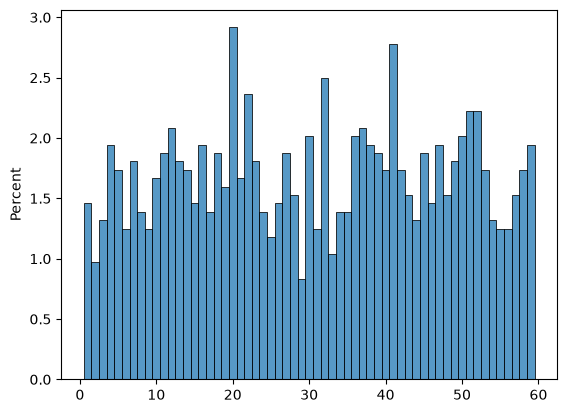

In [120]:
ax = sns.histplot(df_v5[["win_num_1","win_num_2", "win_num_3","win_num_4", "win_num_5"]].to_numpy().flatten(), stat="percent", discrete=True)

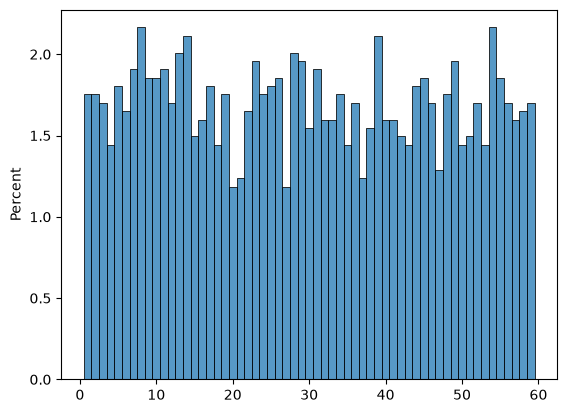

In [125]:
ax = sns.histplot(df_v6[["win_num_1","win_num_2", "win_num_3","win_num_4", "win_num_5"]].to_numpy().flatten(), discrete=True, stat="percent")

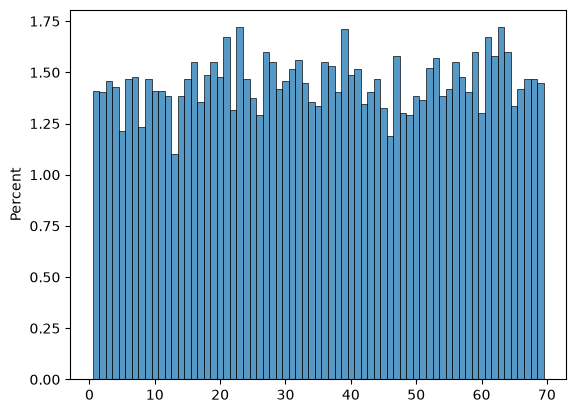

In [126]:
ax = sns.histplot(df_v7[["win_num_1","win_num_2", "win_num_3","win_num_4", "win_num_5"]].to_numpy().flatten(), discrete=True, stat="percent")

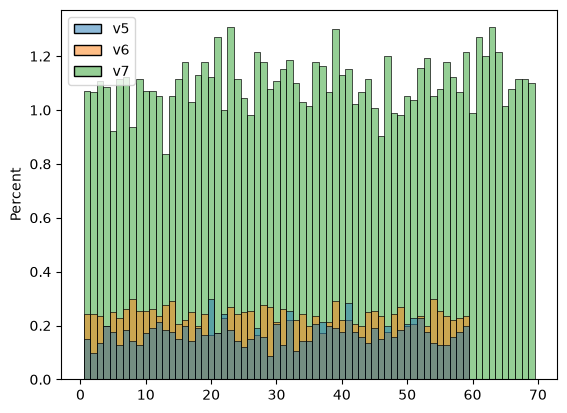

In [128]:
ax = sns.histplot({"v5": df_v5[["win_num_1","win_num_2", "win_num_3","win_num_4", "win_num_5"]].to_numpy().flatten(),
                   "v6": df_v6[["win_num_1","win_num_2", "win_num_3","win_num_4", "win_num_5"]].to_numpy().flatten(),
                   "v7": df_v7[["win_num_1","win_num_2", "win_num_3","win_num_4", "win_num_5"]].to_numpy().flatten()},
                   discrete=True, stat="percent")

<Axes: xlabel='win_num_1', ylabel='Count'>

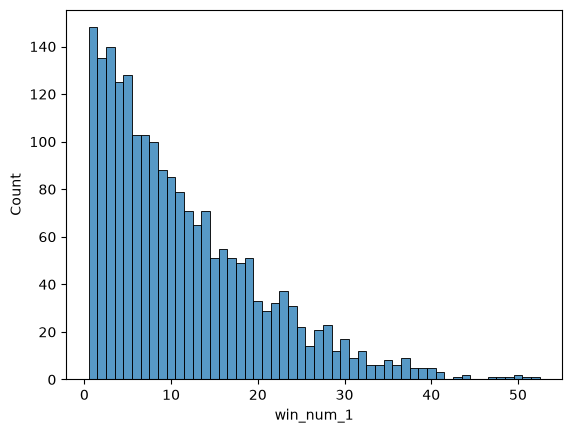

In [95]:
sns.histplot(data=df_pb, x="win_num_1", discrete=True)

<Axes: xlabel='win_num_2', ylabel='Count'>

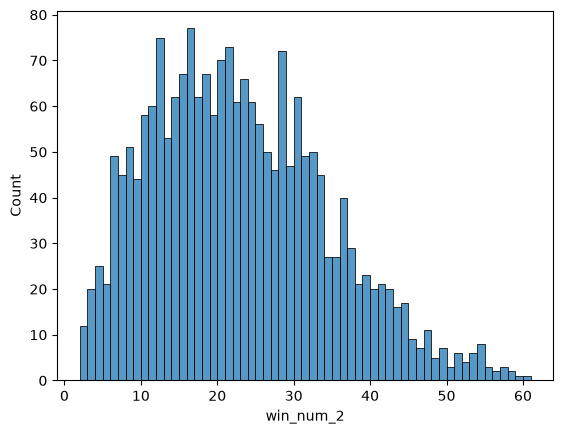

In [63]:
sns.histplot(data=df_pb, x="win_num_2", binwidth=1)

<Axes: xlabel='win_num_3', ylabel='Count'>

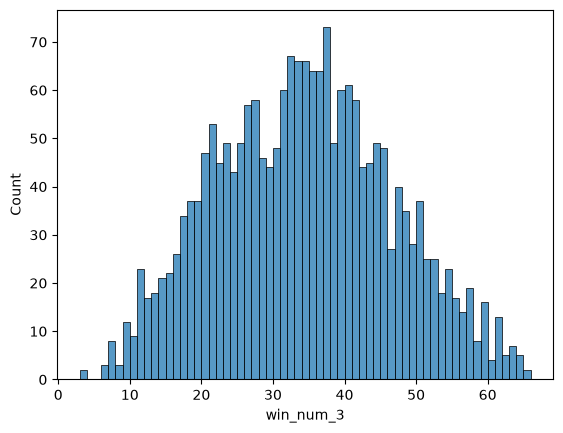

In [65]:
sns.histplot(data=df_pb, x="win_num_3", binwidth=1)

<Axes: xlabel='win_num_4', ylabel='Count'>

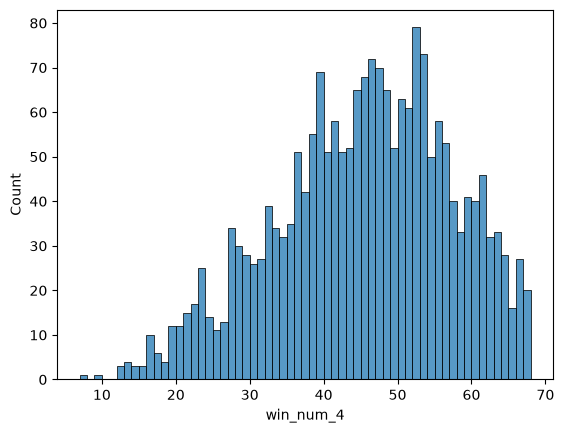

In [66]:
sns.histplot(data=df_pb, x="win_num_4", binwidth=1)